In [ ]:
!pip install upsetplot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators
import numpy as np


BASE = Path(".")
CSV_BASE = BASE / "extended_tool_analisy" / "CSVs"

In [ ]:
TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap"
}

ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap"
]

#normalization
def normalize_doi(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    # cerca un DOI anche dentro stringhe più lunghe
    m = re.search(r"10\.\S+", s)
    if not m:
        return None

    s = m.group(0)
    s = s.rstrip(" .;,)")
    return s or None

def normalize_title(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s or None

#finding columns
DOI_COL_CANDIDATES = [
    "doi", "DOI", "doi_norm", "document_doi", "paper_doi", "work_doi", "citing", "externalIds"
]

TITLE_COL_CANDIDATES = [
    "title", "Title", "paper_title", "document_title", "article_title",
    "display_name", "work_title", "titulo"
]


def find_doi_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in DOI_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "doi" in c.lower():
            return c

    return None


def find_title_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in TITLE_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "title" in c.lower() or "titulo" in c.lower():
            return c

    return None


#read each csv

def read_csv_with_fallback(csv_path: Path):
    for sep in [",", ";", "\t"]:
        try:
            return pd.read_csv(csv_path, sep=sep)
        except Exception:
            pass

    return pd.read_csv(csv_path)

def prepare_normalized_df(csv_path: Path, verbose=True):
    df = read_csv_with_fallback(csv_path)
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    #warning
    if verbose:
        if doi_col is None:
            print(f"[WARNING] {csv_path.name} → colonna DOI NON trovata")
        if title_col is None:
            print(f"[WARNING] {csv_path.name} → colonna TITLE NON trovata")

    if doi_col is not None:
        df["doi_norm"] = df[doi_col].apply(normalize_doi)
    else:
        df["doi_norm"] = None

    if title_col is not None:
        df["title_norm"] = df[title_col].apply(normalize_title)
    else:
        df["title_norm"] = None

    return df, doi_col, title_col

#get duplicates
def get_duplicate_rows(df: pd.DataFrame, col: str):
    """
    Restituisce tutte le righe duplicate rispetto alla colonna col,
    ignorando valori vuoti/non validi.
    """

    valid_mask = (
        df[col].notna() &
        (df[col].astype(str).str.strip() != "") &
        (~df[col].astype(str).str.lower().isin(["nan", "none", "null", "(missing doi", " ", "-"]))
    )

    dup_rows = df.loc[
        valid_mask & df.duplicated(subset=[col], keep=False)
    ].copy()

    if not dup_rows.empty:
        counts = dup_rows[col].value_counts()
        dup_rows[f"{col}_count"] = dup_rows[col].map(counts)
        dup_rows = dup_rows.sort_values(
            by=[col, f"{col}_count"],
            ascending=[True, False]
        )

    return dup_rows

def build_duplicate_value_table(dup_rows: pd.DataFrame, key_col: str, source_file: str):
    """
    Crea una tabella compatta dei duplicati:
    una riga per ogni DOI/titolo duplicato con numero occorrenze.
    """
    if dup_rows.empty:
        return pd.DataFrame()

    out = (
        dup_rows.groupby(key_col, dropna=True)
        .size()
        .reset_index(name="occurrences")
        .sort_values(["occurrences", key_col], ascending=[False, True])
        .reset_index(drop=True)
    )

    out.insert(0, "source_file", source_file)
    out.insert(1, "duplicate_type", key_col.replace("_norm", ""))

    return out


def build_duplicate_report_for_file(csv_path: Path):
    try:
        df, doi_col, title_col = prepare_normalized_df(csv_path, verbose=True)
    except Exception as e:
        return {
            "summary": {
                "file": csv_path.name,
                "rows_total": 0,
                "doi_column": None,
                "title_column": None,
                "doi_non_null": 0,
                "title_non_null": 0,
                "duplicate_doi_groups": 0,
                "duplicate_doi_rows": 0,
                "duplicate_title_groups": 0,
                "duplicate_title_rows": 0,
                "error": str(e)
            },
            "dup_doi_rows": pd.DataFrame(),
            "dup_title_rows": pd.DataFrame(),
            "dup_doi_table": pd.DataFrame(),
            "dup_title_table": pd.DataFrame()
        }

    dup_doi_rows = get_duplicate_rows(df, "doi_norm")
    dup_title_rows = get_duplicate_rows(df, "title_norm")

    dup_doi_table = build_duplicate_value_table(dup_doi_rows, "doi_norm", csv_path.name)
    dup_title_table = build_duplicate_value_table(dup_title_rows, "title_norm", csv_path.name)

    duplicate_doi_groups = dup_doi_rows["doi_norm"].nunique() if not dup_doi_rows.empty else 0
    duplicate_title_groups = dup_title_rows["title_norm"].nunique() if not dup_title_rows.empty else 0

    summary = {
        "file": csv_path.name,
        "rows_total": len(df),
        "doi_column": doi_col,
        "title_column": title_col,
        "doi_non_null": int(df["doi_norm"].notna().sum()),
        "title_non_null": int(df["title_norm"].notna().sum()),
        "duplicate_doi_groups": int(duplicate_doi_groups),
        "duplicate_doi_rows": int(len(dup_doi_rows)),
        "duplicate_title_groups": int(duplicate_title_groups),
        "duplicate_title_rows": int(len(dup_title_rows)),
        "error": None
    }

    return {
        "summary": summary,
        "dup_doi_rows": dup_doi_rows,
        "dup_title_rows": dup_title_rows,
        "dup_doi_table": dup_doi_table,
        "dup_title_table": dup_title_table
    }

def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()
    if "nossatool" in stem:
        return "nossatool"
    if "our_tool" in stem:
        return "our_tool"
    if "snowmap" in stem:
        return "snowmap"

    # General case: remove "artigoXX_" prefix
    parts = stem.split('_', 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    # Fallback if no specific pattern matched
    return stem

def analyze_duplicates_in_folder(folder_path: Path, verbose=True):

    summary_rows = []
    all_dup_doi = []
    all_dup_title = []
    all_dup_tables = []

    csv_files = sorted(
        [
            p for p in folder_path.iterdir()
            if p.is_file()
            and p.suffix.lower() == ".csv"
            #to not analyze some csvs
            and p.stem.lower() != "artigos_relevantes01"
            and p.stem.lower() != "metadados_por_ferramenta"
            and p.stem.lower() != "matriz_metadados_por_ferramenta"
        ]
    )

    for csv_path in csv_files:
        result = build_duplicate_report_for_file(csv_path)

        summary_rows.append(result["summary"])

        dup_doi_rows = result["dup_doi_rows"]
        dup_title_rows = result["dup_title_rows"]
        dup_doi_table = result["dup_doi_table"]
        dup_title_table = result["dup_title_table"]

        if not dup_doi_rows.empty:
            dup_doi_rows = dup_doi_rows.copy()
            dup_doi_rows.insert(0, "source_file", csv_path.name)
            all_dup_doi.append(dup_doi_rows)

        if not dup_title_rows.empty:
            dup_title_rows = dup_title_rows.copy()
            dup_title_rows.insert(0, "source_file", csv_path.name)
            all_dup_title.append(dup_title_rows)

        if not dup_doi_table.empty:
            all_dup_tables.append(dup_doi_table)

        if not dup_title_table.empty:
            all_dup_tables.append(dup_title_table)

        if verbose:
            print(
                f"{csv_path.name} | "
                f"dup_doi_groups={result['summary']['duplicate_doi_groups']} | "
                f"dup_doi_rows={result['summary']['duplicate_doi_rows']} | "
                f"dup_title_groups={result['summary']['duplicate_title_groups']} | "
                f"dup_title_rows={result['summary']['duplicate_title_rows']}"
            )

    summary_df = pd.DataFrame(summary_rows)

    # Add tool column
    summary_df["tool_raw"] = summary_df["file"].apply(extract_tool_from_filename)
    summary_df["tool"] = summary_df["tool_raw"].apply(
        lambda x: TOOL_ALIASES.get(x.lower(), x.lower())
    )

    duplicate_doi_details = (
        pd.concat(all_dup_doi, ignore_index=True)
        if all_dup_doi else pd.DataFrame()
    )

    duplicate_title_details = (
        pd.concat(all_dup_title, ignore_index=True)
        if all_dup_title else pd.DataFrame()
    )

    duplicate_table_df = (
        pd.concat(all_dup_tables, ignore_index=True)
        if all_dup_tables else pd.DataFrame(columns=["source_file", "duplicate_type", "value", "occurrences"])
    )

    if not duplicate_table_df.empty:
        duplicate_table_df = duplicate_table_df.rename(
            columns={"doi_norm": "value", "title_norm": "value"}
        )
        duplicate_table_df = duplicate_table_df[
            ["source_file", "duplicate_type", "value", "occurrences"]
        ]

    return summary_df, duplicate_doi_details, duplicate_title_details, duplicate_table_df


def plot_duplicates_by_file(summary_df):
    if summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = summary_df.copy()

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, plot_df["duplicate_doi_rows"], width, label="Duplicati DOI")
    plt.bar(x + width/2, plot_df["duplicate_title_rows"], width, label="Duplicati Titolo")

    plt.xticks(x, plot_df["file"], rotation=45, ha="right")
    plt.ylabel("Number of duplicate rows")
    plt.title("Duplicates for file: title vs DOI")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_duplicate_groups_by_file(summary_df):
    if summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = summary_df.copy()

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, plot_df["duplicate_doi_groups"], width, label="DOI-based duplicates")
    plt.bar(x + width/2, plot_df["duplicate_title_groups"], width, label="Title-based duplicates")

    plt.xticks(x, plot_df["file"], rotation=45, ha="right")
    plt.ylabel("Numero di gruppi duplicati")
    plt.title("Gruppi di duplicati per file: DOI vs Titolo")
    plt.legend()
    plt.tight_layout()
    plt.show()

#count of rows for each tool for each article
def prepare_plot_df(summary_df, slr_name, count_col="rows_total"):
    df = summary_df.copy()
    df = df.groupby("tool", as_index=False)[count_col].sum()
    df["SLR"] = slr_name
    df = df.rename(columns={count_col: "n_articles"})
    return df[["SLR", "tool", "n_articles"]]

def plot_articles_by_tool_and_slr(plot_df):
    # ordine desiderato
    slr_order = ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]
    tool_order = [
        "googlescholar",
        "lens",
        "openalex",
        "opencitations",
        "semanticscholar",
        "litmaps",
        "researchrabbit",
        "snowmap"
    ]

    # pivot: righe = SLR, colonne = tool
    pivot_df = plot_df.pivot(index="SLR", columns="tool", values="n_articles").fillna(0)

    # forza l'ordine
    pivot_df = pivot_df.reindex(slr_order)
    pivot_df = pivot_df.reindex(columns=[t for t in tool_order if t in pivot_df.columns])

    x = np.arange(len(pivot_df.index))
    n_tools = len(pivot_df.columns)
    width = 0.8 / n_tools

    plt.figure(figsize=(14, 6))

    for i, tool in enumerate(pivot_df.columns):
        plt.bar(
            x + i * width - (n_tools - 1) * width / 2,
            pivot_df[tool].values,
            width=width,
            label=tool
        )

    plt.xticks(x, pivot_df.index)
    plt.xlabel("SLR")
    plt.ylabel("Number of articles")
    plt.title(" ")
    plt.legend(
    title="Tool",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(plot_df["tool"].unique()),
    frameon=False
    )
    plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.tight_layout()
    plt.show()

### **ARTIGO 1**

In [ ]:
folder = CSV_BASE / "new_csvs_slr01"

summary_df1, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder)

display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "doi"])
display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "title"])

artigo01_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=5 | dup_title_rows=10
artigo01_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=2 | dup_title_rows=4
artigo01_litmaps.csv | dup_doi_groups=5 | dup_doi_rows=10 | dup_title_groups=4 | dup_title_rows=8
artigo01_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=3 | dup_title_rows=6
[WARNING] artigo01_openCitations.csv → colonna TITLE NON trovata
artigo01_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo01_researchRabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=9 | dup_title_rows=19
artigo01_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=2 | dup_title_rows=15
artigo01_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=1 | dup_title_rows=2


,source_file,duplicate_type,value,value,occurrences
7,artigo01_litmaps.csv,doi,NaN,10.1145/3503229.3547026,2
8,artigo01_litmaps.csv,doi,NaN,10.1145/3510003.3510190,2
9,artigo01_litmaps.csv,doi,NaN,10.1145/3572905,2
10,artigo01_litmaps.csv,doi,NaN,10.1145/3579027.3608972,2
11,artigo01_litmaps.csv,doi,NaN,10.1145/3579028.3609016,2


,source_file,duplicate_type,value,value,occurrences
0,artigo01_googleScholar.csv,title,cadet debugging and fixing misconfigurations u...,NaN,2
1,artigo01_googleScholar.csv,title,configuration optimization with limited functi...,NaN,2
2,artigo01_googleScholar.csv,title,defining categorical reasoning of numerical fe...,NaN,2
3,artigo01_googleScholar.csv,title,feature models aidriven design analysis and ap...,NaN,2
4,artigo01_googleScholar.csv,title,were not gonna break it consistencypreserving ...,NaN,2
5,artigo01_lens.csv,title,pragmatic random sampling of kconfigbased syst...,NaN,2
6,artigo01_lens.csv,title,towards incremental build of software configur...,NaN,2
12,artigo01_litmaps.csv,title,deep configuration performance learning a syst...,NaN,2
13,artigo01_litmaps.csv,title,llmbased misconfiguration detection for aws se...,NaN,2
14,artigo01_litmaps.csv,title,machine learning for software engineering a te...,NaN,2


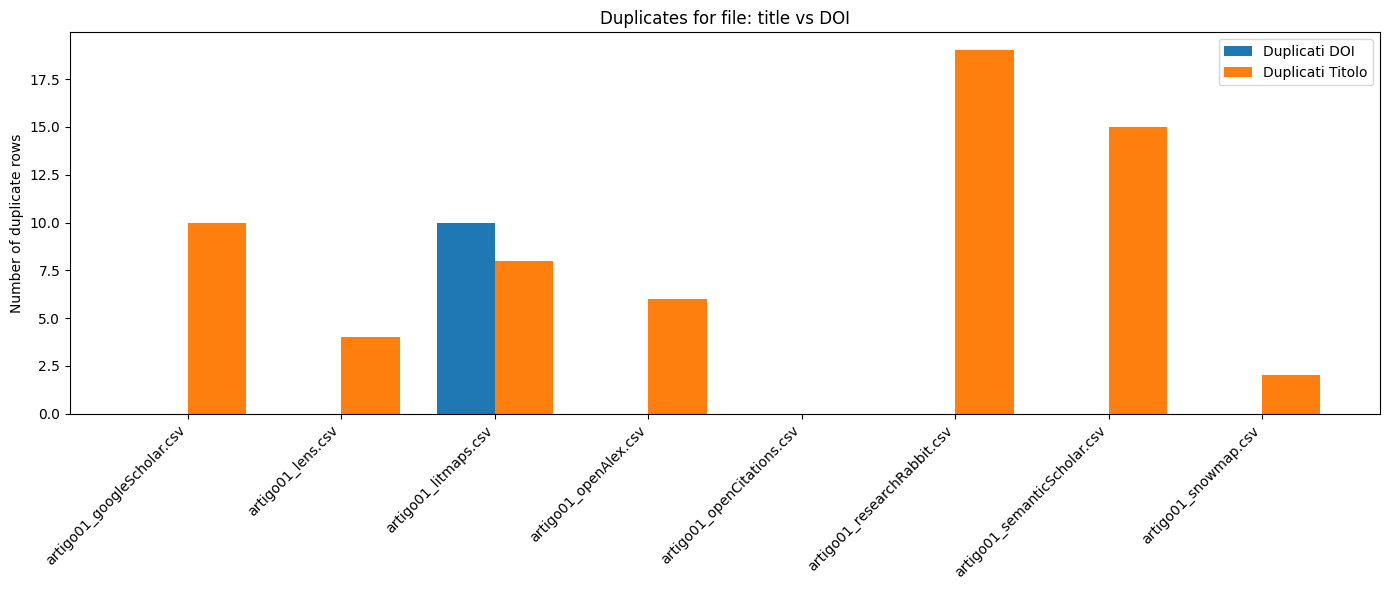

In [ ]:
plot_duplicates_by_file(summary_df1)
#quante righe totali sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 2)

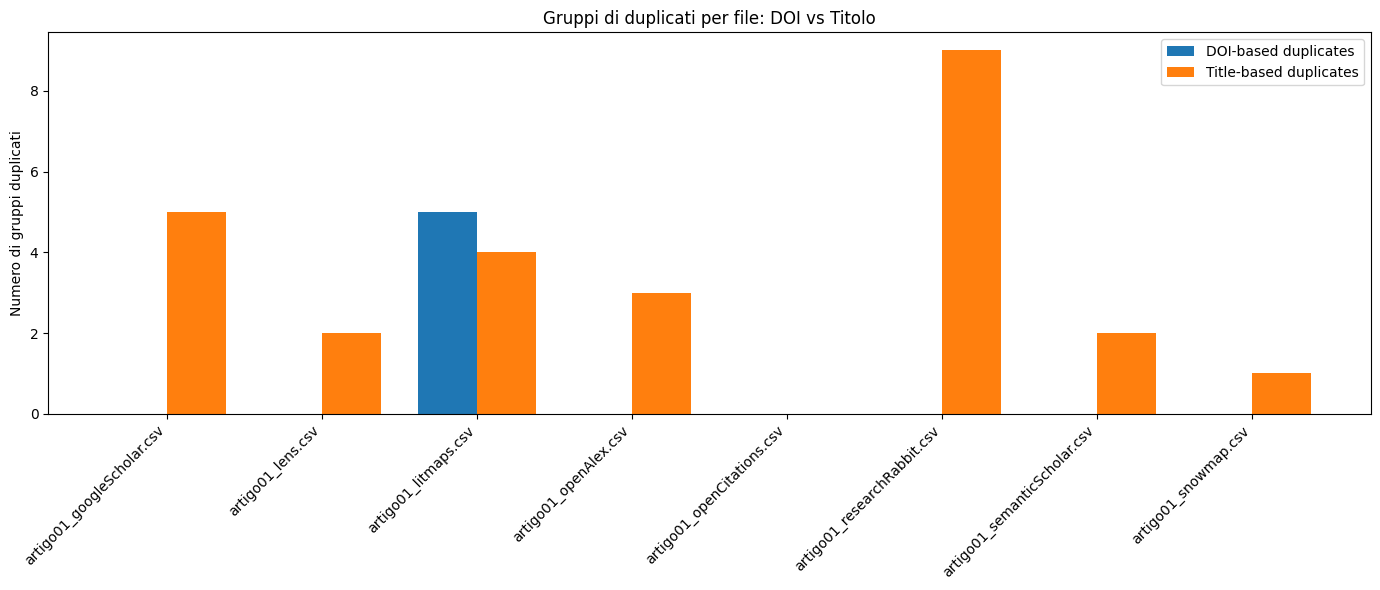

In [ ]:
plot_duplicate_groups_by_file(summary_df1)
#quante righe distinte sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 1)

### **ARTIGO 2**

In [ ]:
folder = CSV_BASE / "new_csvs_slr02"

summary_df2, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder)

display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "doi"])
display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "title"])

artigo02_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_litmaps.csv | dup_doi_groups=3 | dup_doi_rows=6 | dup_title_groups=3 | dup_title_rows=6
artigo02_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo02_openCitations.csv → colonna TITLE NON trovata
artigo02_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_researchRabbit.csv | dup_doi_groups=4 | dup_doi_rows=8 | dup_title_groups=4 | dup_title_rows=8
artigo02_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


,source_file,duplicate_type,value,value,occurrences
0,artigo02_litmaps.csv,doi,10.1007/s42979-020-00420-8,NaN,2
1,artigo02_litmaps.csv,doi,10.1080/15228053.2019.1637087,NaN,2
2,artigo02_litmaps.csv,doi,10.1108/ijcs-09-2018-0024,NaN,2
6,artigo02_researchRabbit.csv,doi,10.1007/s42979-020-00420-8,NaN,2
7,artigo02_researchRabbit.csv,doi,10.1080/15228053.2019.1637087,NaN,2
8,artigo02_researchRabbit.csv,doi,10.1108/ijcs-09-2018-0024,NaN,2
9,artigo02_researchRabbit.csv,doi,10.1108/k-11-2022-1507,NaN,2


,source_file,duplicate_type,value,value,occurrences
3,artigo02_litmaps.csv,title,NaN,an ontologybased approach to automated test ca...,2
4,artigo02_litmaps.csv,title,NaN,challenges and facilitators practices for know...,2
5,artigo02_litmaps.csv,title,NaN,mobile devices compatibility testing strategy ...,2
10,artigo02_researchRabbit.csv,title,NaN,an ontologybased approach to automated test ca...,2
11,artigo02_researchRabbit.csv,title,NaN,challenges and facilitators practices for know...,2
12,artigo02_researchRabbit.csv,title,NaN,mobile devices compatibility testing strategy ...,2
13,artigo02_researchRabbit.csv,title,NaN,which complexity a review of typologies and a ...,2


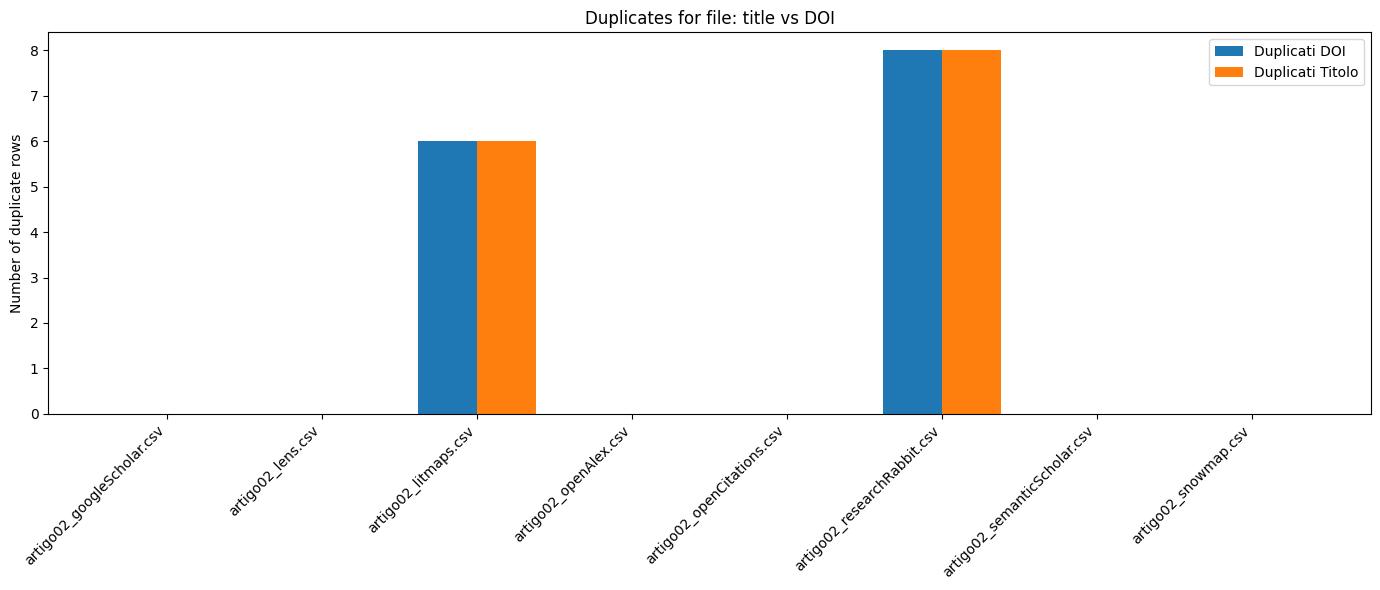

In [ ]:
plot_duplicates_by_file(summary_df2)
#quante righe totali sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 2)

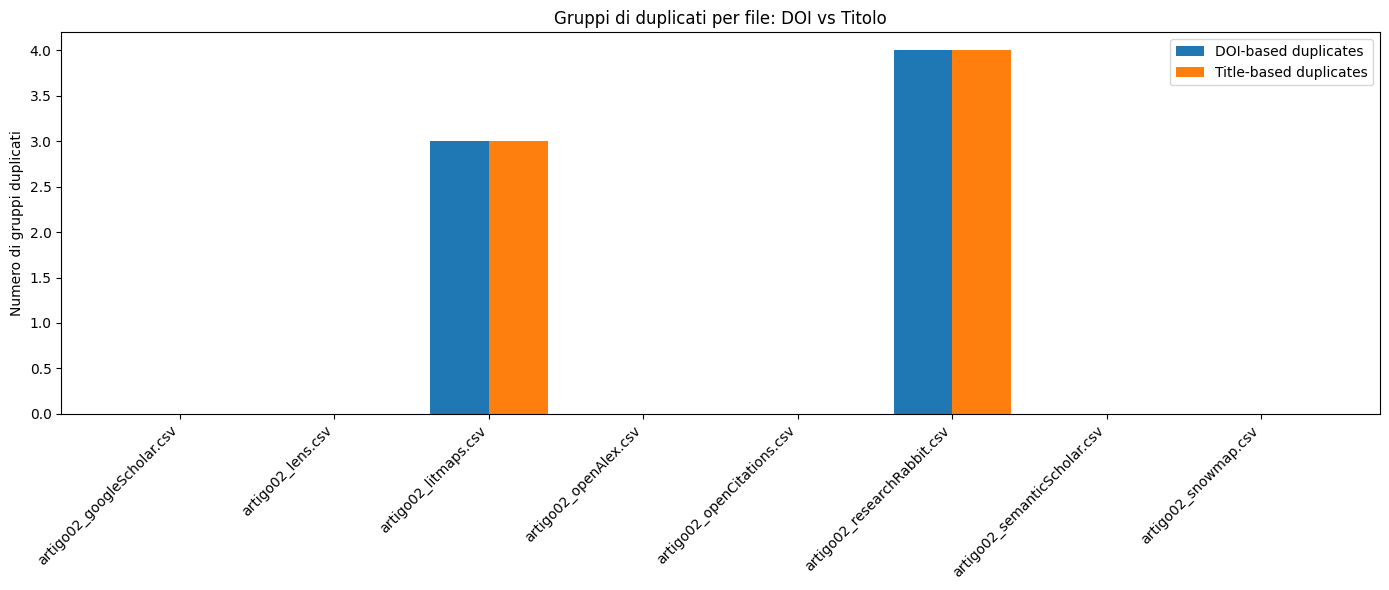

In [ ]:
plot_duplicate_groups_by_file(summary_df2)
#quante righe distinte sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 1)

### **ARTIGO 3**

In [ ]:
folder = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr03")

summary_df3, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder)

display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "doi"])
display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "title"])



artigo03_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=6 | dup_title_rows=12
artigo03_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=5 | dup_title_rows=10
artigo03_litmaps.csv | dup_doi_groups=1 | dup_doi_rows=2 | dup_title_groups=1 | dup_title_rows=2
artigo03_openAlex.csv | dup_doi_groups=1 | dup_doi_rows=2 | dup_title_groups=5 | dup_title_rows=10
[WARNING] artigo03_openCitations.csv → colonna TITLE NON trovata
artigo03_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo03_researchRabbit.csv | dup_doi_groups=14 | dup_doi_rows=31 | dup_title_groups=23 | dup_title_rows=49
artigo03_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=1 | dup_title_rows=2
artigo03_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


,source_file,duplicate_type,value,value,occurrences
11,artigo03_litmaps.csv,doi,NaN,10.5753/sbsi_estendido.2025.246908,2
13,artigo03_openAlex.csv,doi,NaN,10.1109/tse.2021.3070692,2
19,artigo03_researchRabbit.csv,doi,NaN,10.1002/smr.1964,3
20,artigo03_researchRabbit.csv,doi,NaN,10.1002/smr.2235,3
21,artigo03_researchRabbit.csv,doi,NaN,10.1007/s10664-020-09803-0,3
22,artigo03_researchRabbit.csv,doi,NaN,10.1007/s10664-017-9570-9,2
23,artigo03_researchRabbit.csv,doi,NaN,10.1007/s13198-019-00899-2,2
24,artigo03_researchRabbit.csv,doi,NaN,10.1016/j.infsof.2018.12.003,2
25,artigo03_researchRabbit.csv,doi,NaN,10.1016/j.infsof.2019.106225,2
26,artigo03_researchRabbit.csv,doi,NaN,10.1016/j.infsof.2020.106473,2


,source_file,duplicate_type,value,value,occurrences
0,artigo03_googleScholar.csv,title,benefitting from the grey literature in softwa...,NaN,2
1,artigo03_googleScholar.csv,title,detecting latent topics and trends in software...,NaN,2
2,artigo03_googleScholar.csv,title,handson experiences with assistive technologie...,NaN,2
3,artigo03_googleScholar.csv,title,software engineering students soft and hard sk...,NaN,2
4,artigo03_googleScholar.csv,title,successful engagement of practitioners and sof...,NaN,2
5,artigo03_googleScholar.csv,title,towards lean research inception assessing prac...,NaN,2
6,artigo03_lens.csv,title,a survey on software testability,NaN,2
7,artigo03_lens.csv,title,challenges in developing universityindustry re...,NaN,2
8,artigo03_lens.csv,title,framework for simulation software selection,NaN,2
9,artigo03_lens.csv,title,lean software startup practices and software e...,NaN,2


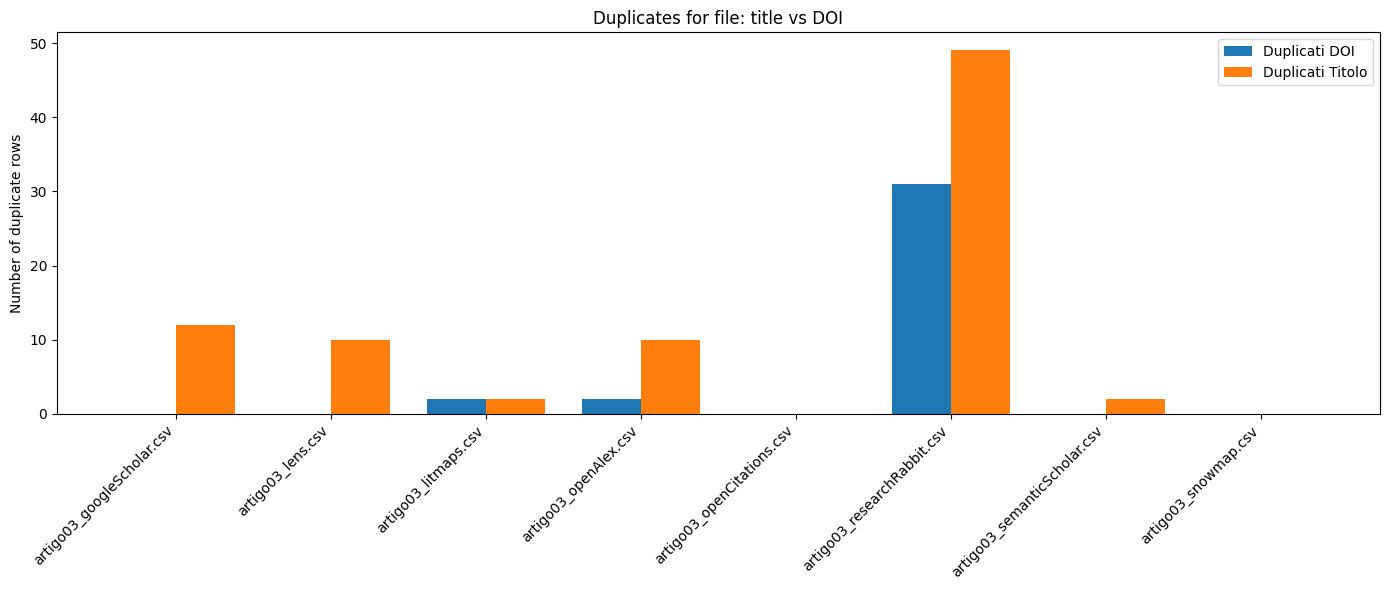

In [ ]:
plot_duplicates_by_file(summary_df3)
#quante righe totali sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 2)

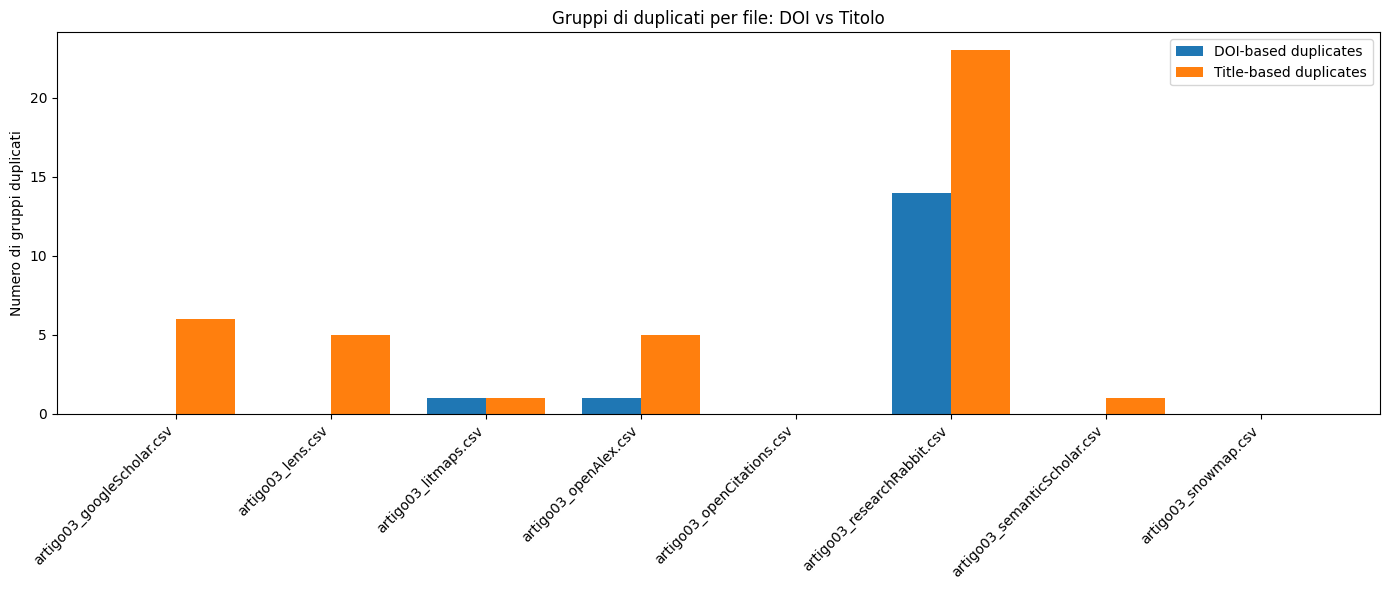

In [ ]:
plot_duplicate_groups_by_file(summary_df3)
#quante righe distinte sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 1)

### **ARTIGO 4**

In [ ]:
folder = CSV_BASE / "new_csvs_slr04"

summary_df4, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder)

display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "doi"])
display(duplicate_table_df[duplicate_table_df["duplicate_type"] == "title"])

artigo04_googleScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_litmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_openAlex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo04_openCitations.csv → colonna TITLE NON trovata
artigo04_openCitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_researchRabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_semanticScholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo04_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


,source_file,duplicate_type,value,occurrences


,source_file,duplicate_type,value,occurrences


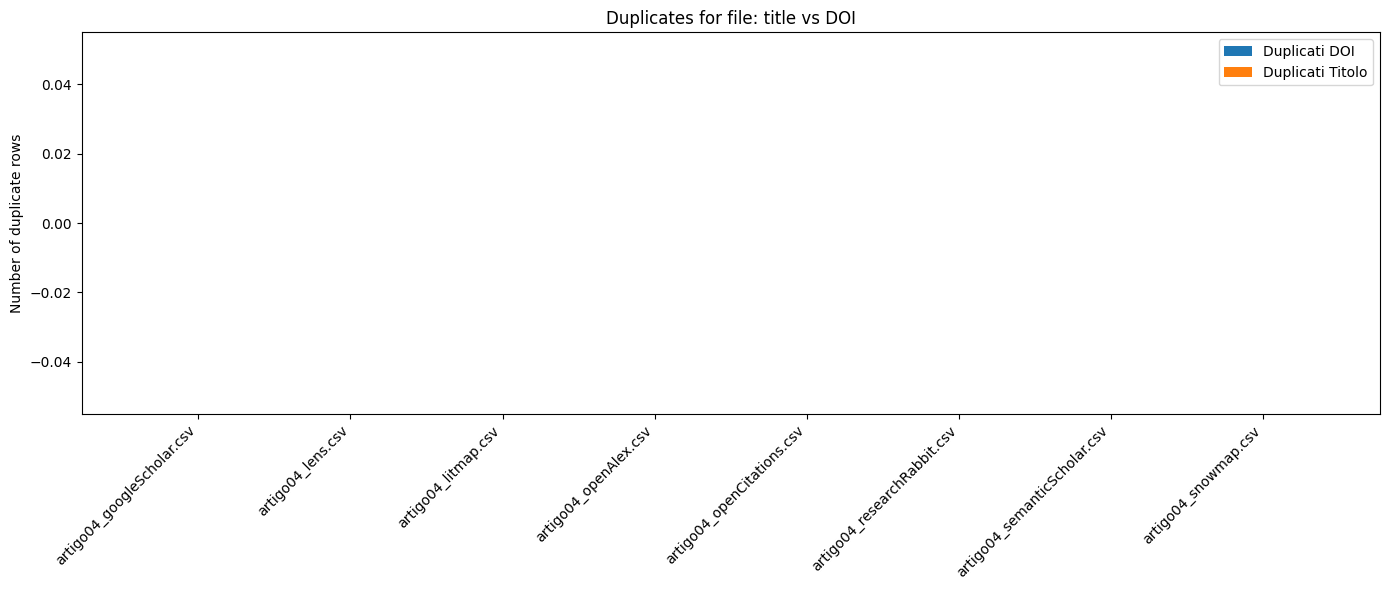

In [ ]:
plot_duplicates_by_file(summary_df4)
#quante righe totali sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 2)

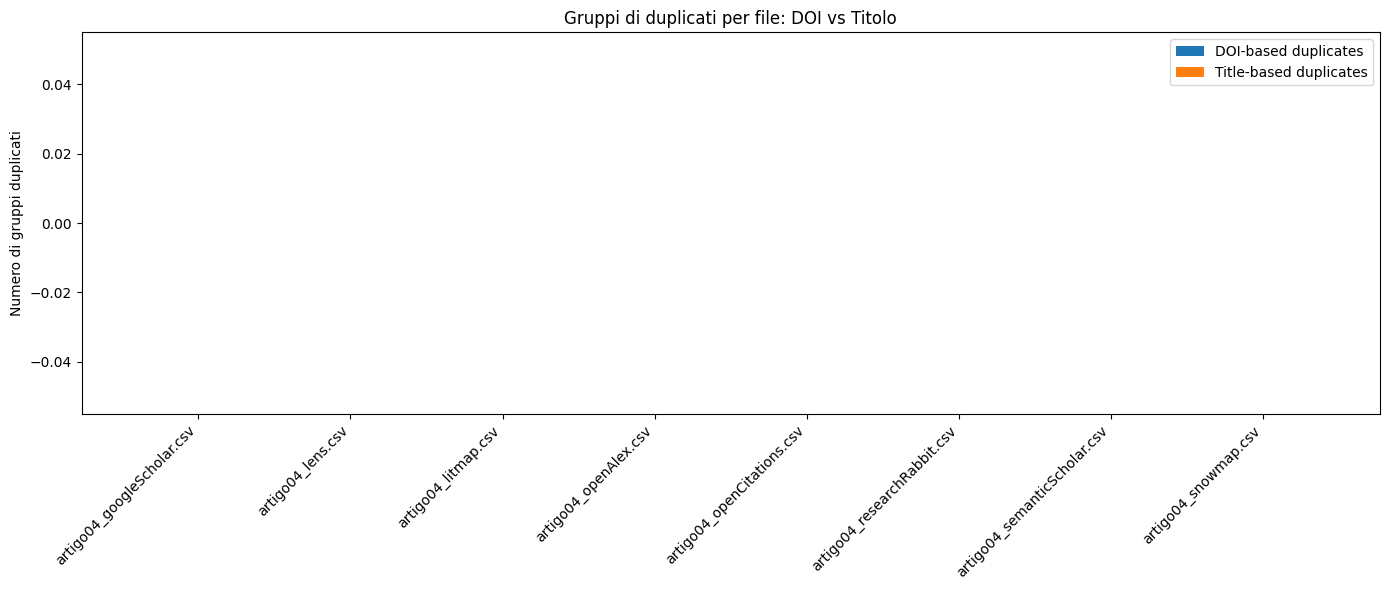

In [ ]:
plot_duplicate_groups_by_file(summary_df4)
#quante righe distinte sono duplicate (ad esempio se riga 2323 si ripete 2 volte lui conta 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_duplicates_2x2(summary_df1, summary_df2, summary_df3, summary_df4):
    slr_tables = {
        "SLR 1": summary_df1.copy(),
        "SLR 2": summary_df2.copy(),
        "SLR 3": summary_df3.copy(),
        "SLR 4": summary_df4.copy(),
    }

    tool_order = [
        "googlescholar",
        "lens",
        "openalex",
        "opencitations",
        "semanticscholar",
        "litmaps",
        "researchrabbit",
        "snowmap"
    ]

    palette = plt.get_cmap("tab10")
    colors = {
        "DOI-based duplicates": palette(0),
        "Title-based duplicates": palette(1)
    }

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
    axes = axes.flatten()

    handles, labels = None, None

    for ax, (slr, df) in zip(axes, slr_tables.items()):
        df = df.copy()

        # normalizza nomi tool
        df["tool"] = df["tool"].astype(str).str.strip().str.lower()

        # aggrega per tool
        plot_df = (
            df.groupby("tool", as_index=False)[
                ["duplicate_doi_rows", "duplicate_title_rows"]
            ]
            .sum()
        )

        # ordine fisso
        plot_df = (
            plot_df.set_index("tool")
            .reindex(tool_order, fill_value=0)
            .reset_index()
        )

        x = np.arange(len(plot_df))
        width = 0.38

        bars1 = ax.bar(
            x - width/2,
            plot_df["duplicate_doi_rows"],
            width,
            label="DOI-based duplicates",
            color=colors["DOI-based duplicates"]
        )
        bars2 = ax.bar(
            x + width/2,
            plot_df["duplicate_title_rows"],
            width,
            label="Title-based duplicates",
            color=colors["Title-based duplicates"]
        )

        ax.set_title(slr, fontsize=14, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["tool"], rotation=25, ha="right", fontsize=11, color="black")
        ax.tick_params(axis="y", labelsize=11, colors="black")
        ax.tick_params(axis="x", colors="black")
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    axes[0].set_ylabel("Number of duplicate rows", fontsize=12, color="black")
    axes[2].set_ylabel("Number of duplicate rows", fontsize=12, color="black")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.03),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

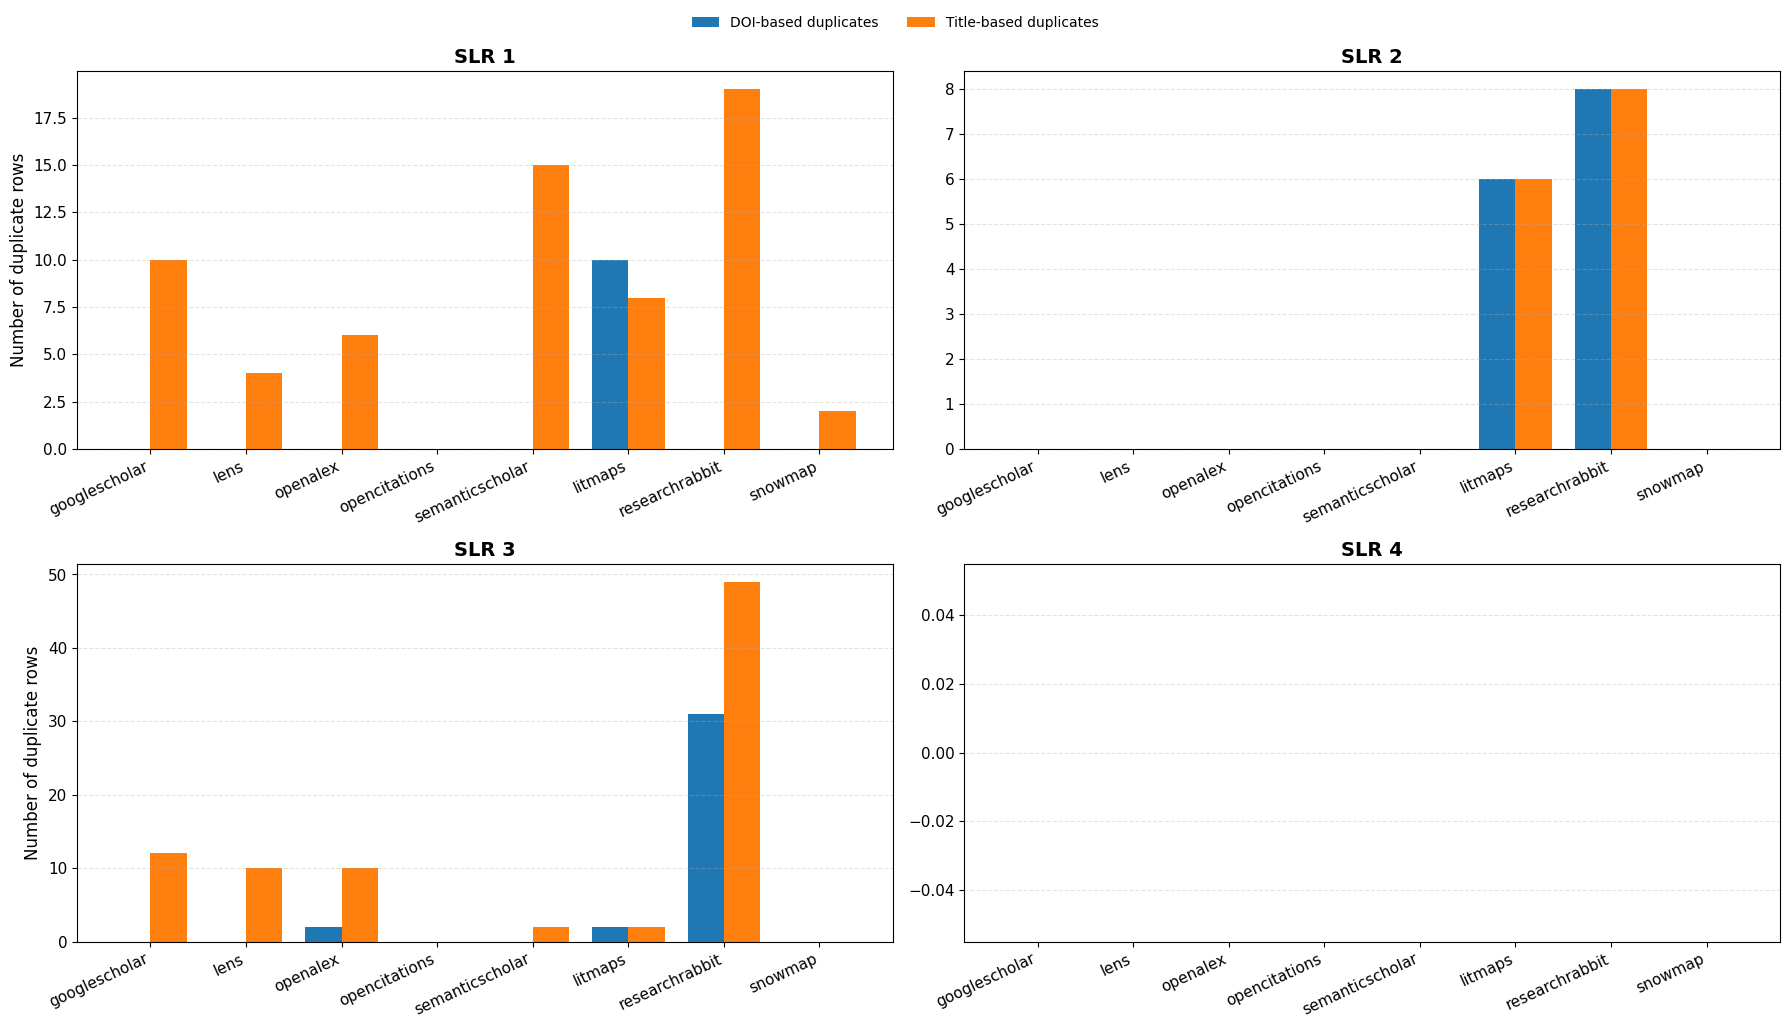

In [ ]:
plot_duplicates_2x2(summary_df1, summary_df2, summary_df3, summary_df4)

### **NUMBER OF ROWS FOR EACH TOOL FOR EACH SRL**


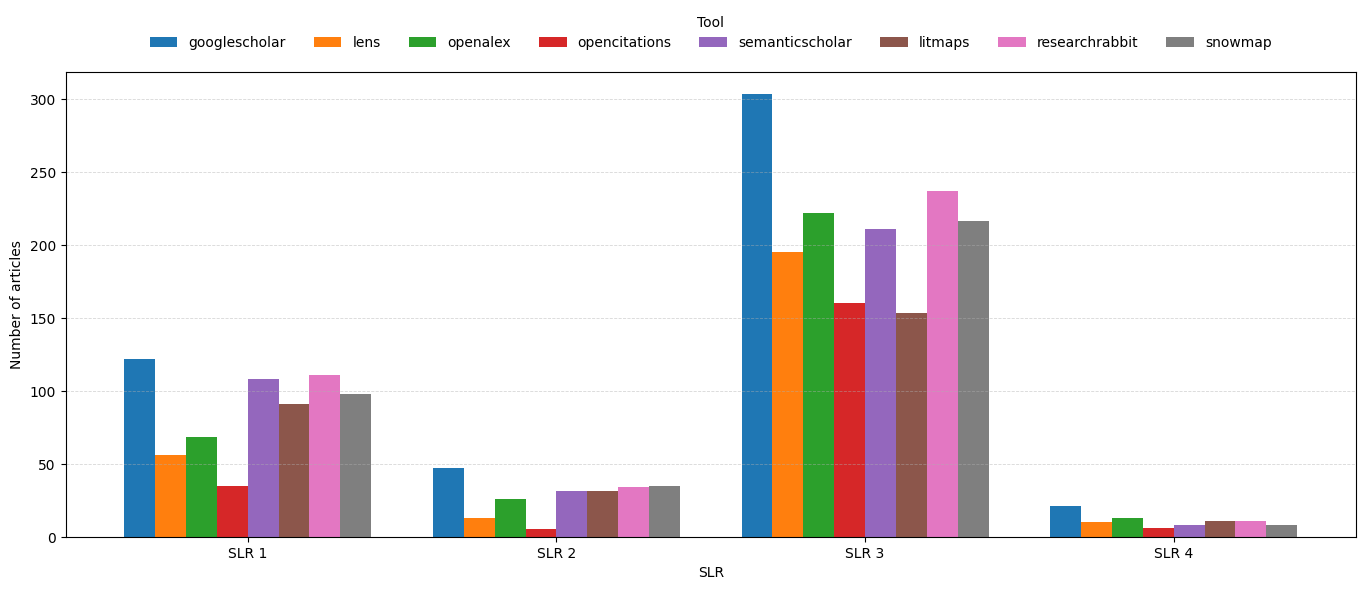

In [ ]:
plot_slr1 = prepare_plot_df(summary_df1, "SLR 1")
plot_slr2 = prepare_plot_df(summary_df2, "SLR 2")
plot_slr3 = prepare_plot_df(summary_df3, "SLR 3")
plot_slr4 = prepare_plot_df(summary_df4, "SLR 4")

plot_df = pd.concat([plot_slr1, plot_slr2, plot_slr3, plot_slr4], ignore_index=True)
plot_df
plot_articles_by_tool_and_slr(plot_df)
